# Transferable Chlorophyll-a Estimation: Addressing Optical Differences

This notebook implements a Random Forest model that accounts for the optical differences between Upper Klamath Lake (shallow, turbid) and Detroit Lake (deep, clear) to achieve better transferability and seasonal pattern preservation.

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Process the MODIS 500 m MOD09GA Data using Google Earth Engine (GEE)

### Notes

1. Adjust the date range if needed (currently 2011-2025)
2. The code exports CSV files to your local directory
3. Two CSV files are exported for each lake: `[Lake]_Terra.csv` and `[Lake]_Aqua.csv`

The code extracts:

- Band 1 (Red, 620-670 nm) 
- Band 2 (NIR, 841-876 nm)
- Band 4 (Green, 545-565 nm)
- Calculated ratios: NIR/Red, Green/Red, and NDCI

After running the following GEE cell, the CSV files it produces will be used for the rest of the analysis.

The exported CSV files will contain columns:

- `datetime`, `date`, `time`, `sensor`
- `band1_red`, `band2_nir`, `band4_green`
- `nir_red_ratio`, `green_red_ratio`, `ndci`

In [20]:
# ============================================
# Google Earth Engine MODIS Data Extraction
# ============================================

# Cell 1: Import and Initialize GEE
import ee
import pandas as pd
import numpy as np
from datetime import datetime

# Authenticate and initialize GEE
ee.Authenticate()
ee.Initialize(project='ee-toddsteissberg')  # Replace with your GEE project ID

print("GEE initialized successfully!")

# ============================================
# Cell 2: Configuration Parameters
# ============================================

# Configuration parameters
CONFIG = {
    'lakes': [
        {
            'name': 'UpperKlamath',
            'lon': -121.900,
            'lat': 42.400,
            'export_prefix': 'UKL_MODIS_Multiband_ML'
        },
        {
            'name': 'Detroit',
            'lon': -122.184,
            'lat': 44.711,
            'export_prefix': 'Detroit_MODIS_Multiband_ML'
        }
    ],
    'start_date': '2011-01-01',
    'end_date': '2025-12-31',
    'roi_radius_m': 1000,
    'shoreline_buffer_m': 500,
    'water_occ_threshold': 75,
    'terra_collection': 'MODIS/061/MOD09GA',
    'aqua_collection': 'MODIS/061/MYD09GA',
    'gsw_dataset': 'JRC/GSW1_4/GlobalSurfaceWater',
    'sr_scale': 1e-4
}

print("Configuration loaded")
print(f"Processing lakes: {[lake['name'] for lake in CONFIG['lakes']]}")
print(f"Date range: {CONFIG['start_date']} to {CONFIG['end_date']}")

# ============================================
# Cell 3: Define Masking Functions
# ============================================

def mask_mod09(img):
    """
    Apply quality masks to MODIS imagery.
    Uses state_1km band for cloud, shadow, and other quality flags.
    """
    qa = img.select('state_1km')
    
    # Cloud state (bits 0-1): 0=clear, 1=cloudy, 2=mixed, 3=not set
    cloud_state = qa.bitwiseAnd(3)
    cloudy_or_mixed = cloud_state.eq(1).Or(cloud_state.eq(2))
    
    # Other quality flags
    shadow = qa.bitwiseAnd(1 << 2).neq(0)    # bit 2: cloud shadow
    cirrus = qa.bitwiseAnd(3 << 8).neq(0)    # bits 8-9: cirrus detected
    intcloud = qa.bitwiseAnd(1 << 10).neq(0) # bit 10: internal cloud
    snowice = qa.bitwiseAnd(1 << 12).neq(0)  # bit 12: snow/ice
    
    # Combine all masks
    mask = cloudy_or_mixed.Or(shadow).Or(cirrus).Or(intcloud).Or(snowice).Not()
    return img.updateMask(mask)

def build_water_mask():
    """
    Create persistent water mask from JRC Global Surface Water.
    Erodes shoreline to avoid mixed pixels.
    """
    gsw = ee.Image(CONFIG['gsw_dataset']).select('occurrence')
    water = gsw.gte(CONFIG['water_occ_threshold'])
    water_eroded = water.focal_min(
        radius=CONFIG['shoreline_buffer_m'], 
        units='meters'
    )
    return water_eroded

# Create water mask
WATER_MASK = build_water_mask()
print("Water mask created")

# ============================================
# Cell 4: Define Feature Extraction Function
# ============================================

def extract_multiband_stats(img, roi_geom, sensor_tag):
    """
    Extract all three MODIS bands plus computed indices.
    Returns a feature with band values and metadata.
    """
    # Apply masks
    img = mask_mod09(img).updateMask(WATER_MASK)
    
    # Extract and scale bands
    red = img.select('sur_refl_b01').multiply(CONFIG['sr_scale'])
    nir = img.select('sur_refl_b02').multiply(CONFIG['sr_scale'])
    green = img.select('sur_refl_b04').multiply(CONFIG['sr_scale'])
    
    # Check for valid pixels
    valid = red.gt(0).And(nir.gt(0)).And(green.gt(0))
    
    # Stack bands for reduction
    multiband = ee.Image.cat([
        red.updateMask(valid).rename('band1_red'),
        nir.updateMask(valid).rename('band2_nir'),
        green.updateMask(valid).rename('band4_green')
    ])
    
    # Calculate band ratios for comparison
    nir_red_ratio = nir.divide(red).updateMask(valid).rename('nir_red_ratio')
    green_red_ratio = green.divide(red).updateMask(valid).rename('green_red_ratio')
    ndci = nir.subtract(red).divide(nir.add(red)).updateMask(valid).rename('ndci')
    
    # Combine all bands and indices
    all_bands = multiband.addBands([nir_red_ratio, green_red_ratio, ndci])
    
    # Reduce over ROI using median
    stats = all_bands.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=roi_geom,
        scale=500,
        maxPixels=1e9,
        bestEffort=True
    )
    
    # Create feature with properties
    props = ee.Dictionary({
        'datetime': ee.Date(img.get('system:time_start')).format('YYYY-MM-dd HH:mm:ss'),
        'date': ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
        'time': ee.Date(img.get('system:time_start')).format('HH:mm:ss'),
        'sensor': sensor_tag,
        'band1_red': stats.get('band1_red'),
        'band2_nir': stats.get('band2_nir'),
        'band4_green': stats.get('band4_green'),
        'nir_red_ratio': stats.get('nir_red_ratio'),
        'green_red_ratio': stats.get('green_red_ratio'),
        'ndci': stats.get('ndci')
    })
    
    return ee.Feature(None, props)

def process_collection(col_id, roi_geom, sensor_tag):
    """
    Process an entire image collection.
    """
    ic = (ee.ImageCollection(col_id)
          .filterDate(CONFIG['start_date'], CONFIG['end_date'])
          .filterBounds(roi_geom))
    
    fc = ic.map(lambda img: extract_multiband_stats(img, roi_geom, sensor_tag))
    fc = fc.filter(ee.Filter.notNull(['band1_red', 'band2_nir', 'band4_green']))
    
    return fc

print("Processing functions defined")

# ============================================
# Cell 5: Process and Export Data
# ============================================

# Process and export data for each lake
exported_files = {}

for lake in CONFIG['lakes']:
    print(f"\nProcessing {lake['name']} Lake...")
    
    # Create ROI
    center = ee.Geometry.Point([lake['lon'], lake['lat']])
    roi = center.buffer(CONFIG['roi_radius_m'])
    
    # Process Terra
    print("  Processing Terra...")
    terra_fc = process_collection(CONFIG['terra_collection'], roi, 'Terra')
    terra_size = terra_fc.size().getInfo()
    print(f"    Found {terra_size} valid Terra observations")
    
    # Process Aqua
    print("  Processing Aqua...")
    aqua_fc = process_collection(CONFIG['aqua_collection'], roi, 'Aqua')
    aqua_size = aqua_fc.size().getInfo()
    print(f"    Found {aqua_size} valid Aqua observations")
    
    # Export to local CSV files
    print("  Exporting data...")
    
    # Terra export
    terra_rows = terra_fc.getInfo()['features']
    terra_records = [f['properties'] for f in terra_rows]
    terra_df = pd.DataFrame.from_records(terra_records)
    
    if len(terra_df) > 0:
        terra_df = terra_df.sort_values('datetime')
        terra_filename = f"{lake['export_prefix']}_Terra.csv"
        terra_df.to_csv(terra_filename, index=False)
        print(f"  Exported: {terra_filename} ({len(terra_df)} records)")
    else:
        print(f"  WARNING: No Terra data for {lake['name']}")
        terra_filename = None
    
    # Aqua export
    aqua_rows = aqua_fc.getInfo()['features']
    aqua_records = [f['properties'] for f in aqua_rows]
    aqua_df = pd.DataFrame.from_records(aqua_records)
    
    if len(aqua_df) > 0:
        aqua_df = aqua_df.sort_values('datetime')
        aqua_filename = f"{lake['export_prefix']}_Aqua.csv"
        aqua_df.to_csv(aqua_filename, index=False)
        print(f"  Exported: {aqua_filename} ({len(aqua_df)} records)")
    else:
        print(f"  WARNING: No Aqua data for {lake['name']}")
        aqua_filename = None
    
    # Store filenames
    exported_files[lake['name']] = {
        'terra': terra_filename,
        'aqua': aqua_filename
    }

print("\n" + "="*50)
print("GEE data extraction complete!")
print("="*50)

# ============================================
# Cell 6: Verify Exported Data
# ============================================

print("\nVerifying exported data...")

for lake_name, files in exported_files.items():
    print(f"\n{lake_name} Lake:")
    
    # Check Terra
    if files['terra']:
        terra_df = pd.read_csv(files['terra'])
        print(f"  Terra: {len(terra_df)} observations")
        print(f"    Date range: {terra_df['date'].min()} to {terra_df['date'].max()}")
        print(f"    Band1 (Red) range: {terra_df['band1_red'].min():.4f} - {terra_df['band1_red'].max():.4f}")
        print(f"    Band2 (NIR) range: {terra_df['band2_nir'].min():.4f} - {terra_df['band2_nir'].max():.4f}")
        print(f"    Band4 (Green) range: {terra_df['band4_green'].min():.4f} - {terra_df['band4_green'].max():.4f}")
    
    # Check Aqua
    if files['aqua']:
        aqua_df = pd.read_csv(files['aqua'])
        print(f"  Aqua: {len(aqua_df)} observations")
        print(f"    Date range: {aqua_df['date'].min()} to {aqua_df['date'].max()}")

print("\nAll data exported successfully!")
print("\nNext steps:")
print("1. Use these CSV files for the ML model training")
print("2. Match with in-situ chlorophyll data")
print("3. Train and apply the transferable models")

# ============================================
# Optional: Quick Data Quality Check
# ============================================

print("\n" + "="*50)
print("Quick Data Quality Check")
print("="*50)

for lake_name in ['UpperKlamath', 'Detroit']:
    if lake_name in exported_files and exported_files[lake_name]['terra']:
        df = pd.read_csv(exported_files[lake_name]['terra'])
        
        # Check for potential issues
        print(f"\n{lake_name} Data Quality:")
        
        # Check for NaN values
        nan_counts = df.isna().sum()
        if nan_counts.any():
            print("  WARNING: NaN values found:")
            print(nan_counts[nan_counts > 0])
        else:
            print("  ✓ No NaN values")
        
        # Check for outliers (simple threshold)
        outliers = (df['band1_red'] > 0.5) | (df['band2_nir'] > 0.7) | (df['band4_green'] > 0.6)
        if outliers.any():
            print(f"  ⚠ Potential outliers: {outliers.sum()} observations with very high reflectance")
        else:
            print("  ✓ No obvious outliers")
        
        # Check temporal coverage
        df['date'] = pd.to_datetime(df['date'])
        df['year'] = df['date'].dt.year
        yearly_counts = df.groupby('year').size()
        print(f"  Observations per year:")
        print(f"    Min: {yearly_counts.min()} ({yearly_counts.idxmin()})")
        print(f"    Max: {yearly_counts.max()} ({yearly_counts.idxmax()})")
        print(f"    Mean: {yearly_counts.mean():.1f}")

GEE initialized successfully!
Configuration loaded
Processing lakes: ['UpperKlamath', 'Detroit']
Date range: 2011-01-01 to 2025-12-31
Water mask created
Processing functions defined

Processing UpperKlamath Lake...
  Processing Terra...
    Found 2496 valid Terra observations
  Processing Aqua...
    Found 2395 valid Aqua observations
  Exporting data...
  Exported: UKL_MODIS_Multiband_ML_Terra.csv (2496 records)
  Exported: UKL_MODIS_Multiband_ML_Aqua.csv (2395 records)

Processing Detroit Lake...
  Processing Terra...
    Found 1931 valid Terra observations
  Processing Aqua...
    Found 2002 valid Aqua observations
  Exporting data...
  Exported: Detroit_MODIS_Multiband_ML_Terra.csv (1931 records)
  Exported: Detroit_MODIS_Multiband_ML_Aqua.csv (2002 records)

GEE data extraction complete!

Verifying exported data...

UpperKlamath Lake:
  Terra: 2496 observations
    Date range: 2011-01-18 to 2025-08-18
    Band1 (Red) range: 0.0001 - 0.4915
    Band2 (NIR) range: 0.0001 - 0.5182
  

## 2. Load UKL In-Situ Data

In [2]:
def load_ukl_insitu_data(file_path):
    """
    Load UKL in situ chlorophyll data from Excel file.
    Handles various date formats including Excel serial dates.
    """
    print(f"Loading UKL in situ data from: {file_path}")
    
    # Read the Excel file
    df = pd.read_excel(file_path)
    
    # Filter for chlorophyll measurements
    chl_data = df[df['CharacteristicName'] == 'Chlorophyll a'].copy()
    
    print(f"Found {len(chl_data)} chlorophyll measurements")
    
    # Process the data
    processed_data = []
    
    for _, row in chl_data.iterrows():
        try:
            # Handle date parsing
            date_value = row['ActivityStartDate']
            
            if isinstance(date_value, (int, float)):
                # Excel serial date
                date = pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(date_value))
            else:
                date = pd.to_datetime(date_value)
            
            # Get chlorophyll value
            chl_value = float(row['ResultMeasureValue'])
            if chl_value <= 0 or pd.isna(chl_value):
                continue
            
            processed_data.append({
                'datetime': date,
                'chlorophyll_a': chl_value,
                'organization': row['OrganizationIdentifier'],
                'location': row['MonitoringLocationName']
            })
            
        except Exception as e:
            continue
    
    # Create DataFrame
    insitu_df = pd.DataFrame(processed_data)
    insitu_df = insitu_df.sort_values('datetime').reset_index(drop=True)
    
    # Basic statistics
    print(f"\nData Summary:")
    print(f"Date range: {insitu_df['datetime'].min()} to {insitu_df['datetime'].max()}")
    print(f"Chlorophyll range: {insitu_df['chlorophyll_a'].min():.1f} - {insitu_df['chlorophyll_a'].max():.1f} µg/L")
    print(f"Mean: {insitu_df['chlorophyll_a'].mean():.1f} µg/L")
    print(f"Median: {insitu_df['chlorophyll_a'].median():.1f} µg/L")
    
    return insitu_df

# Load the actual data
ukl_insitu = load_ukl_insitu_data('../Data/Upper_Klamath_Lake/Klamath K.xlsx')

# Filter outliers for satellite calibration
ukl_insitu_filtered = ukl_insitu[
    (ukl_insitu['chlorophyll_a'] >= 1.0) & 
    (ukl_insitu['chlorophyll_a'] <= 500.0)
].copy()

print(f"\nFiltered to {len(ukl_insitu_filtered)} measurements for calibration")

Loading UKL in situ data from: ../Data/Upper_Klamath_Lake/Klamath K.xlsx
Found 1486 chlorophyll measurements

Data Summary:
Date range: 2011-04-18 00:00:00 to 2018-10-23 00:00:00
Chlorophyll range: 0.8 - 1341.3 µg/L
Mean: 57.5 µg/L
Median: 23.9 µg/L

Filtered to 1476 measurements for calibration


## 3. Load MODIS Data and Analyze Optical Differences

In [3]:
# Load MODIS data (assuming already exported from GEE)
print("Loading MODIS data...")

# Upper Klamath Lake
ukl_terra = pd.read_csv('UKL_MODIS_Multiband_ML_Terra.csv')
ukl_aqua = pd.read_csv('UKL_MODIS_Multiband_ML_Aqua.csv')
ukl_modis = pd.concat([ukl_terra, ukl_aqua], ignore_index=True)
ukl_modis['datetime'] = pd.to_datetime(ukl_modis['datetime'])
ukl_modis = ukl_modis.sort_values('datetime').reset_index(drop=True)

# Detroit Lake
detroit_terra = pd.read_csv('Detroit_MODIS_Multiband_ML_Terra.csv')
detroit_aqua = pd.read_csv('Detroit_MODIS_Multiband_ML_Aqua.csv')
detroit_modis = pd.concat([detroit_terra, detroit_aqua], ignore_index=True)
detroit_modis['datetime'] = pd.to_datetime(detroit_modis['datetime'])
detroit_modis = detroit_modis.sort_values('datetime').reset_index(drop=True)

print(f"UKL MODIS observations: {len(ukl_modis)}")
print(f"Detroit MODIS observations: {len(detroit_modis)}")

Loading MODIS data...
UKL MODIS observations: 4890
Detroit MODIS observations: 3933



=== Optical Properties Analysis ===

Mean Band Ratios:
  Upper Klamath Lake:
    NIR/Red: 0.643
    Green/Red: 1.485
  Detroit Lake:
    NIR/Red: 4.751
    Green/Red: 1.515

Ratio Differences (Detroit/UKL):
  NIR/Red: 7.4x difference
  Green/Red: 1.0x difference


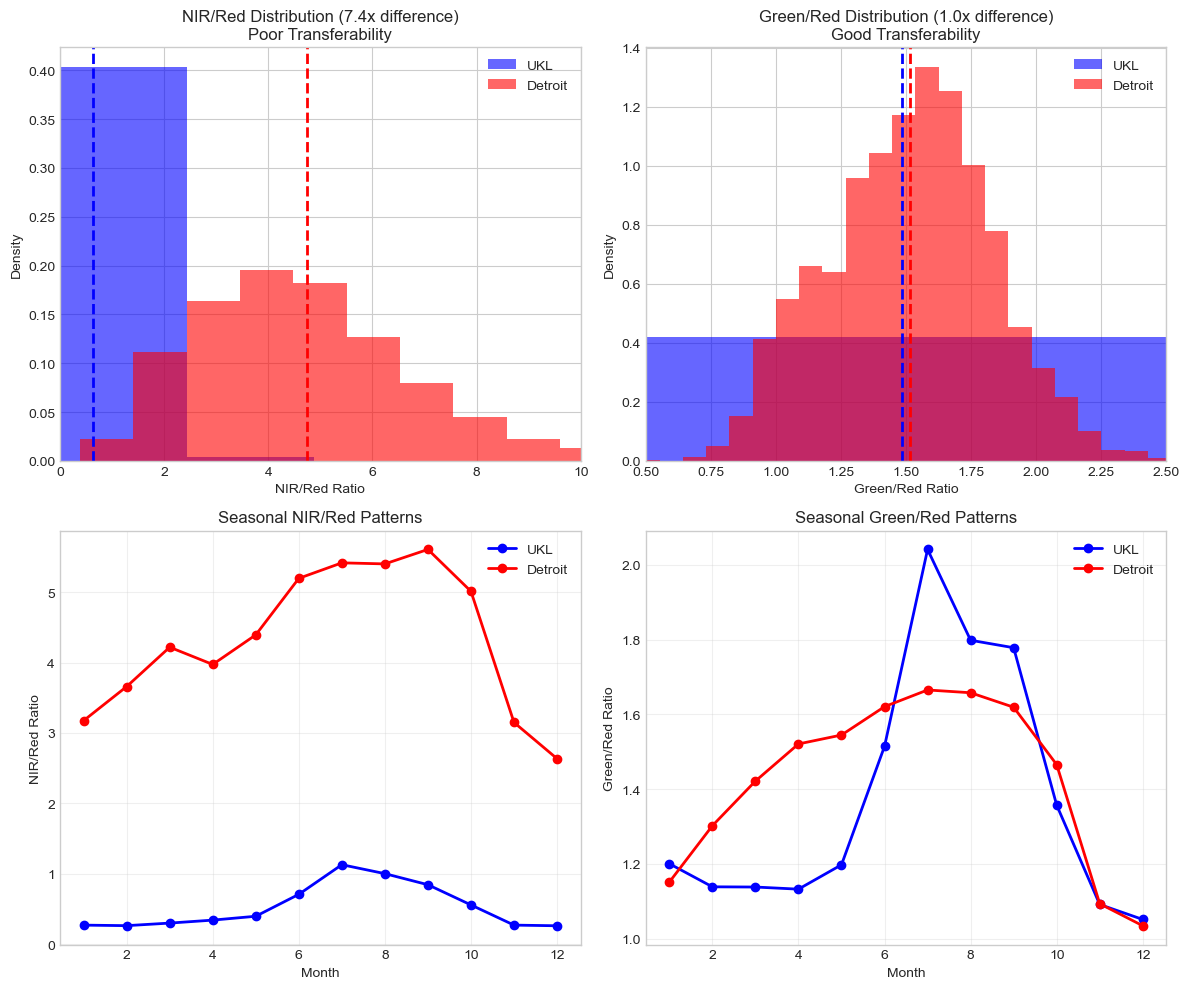

In [4]:
# Analyze optical differences between lakes
def analyze_optical_properties(ukl_modis, detroit_modis):
    """
    Compare optical properties between lakes to understand transferability issues.
    """
    print("\n=== Optical Properties Analysis ===")
    
    # Calculate ratios
    ukl_modis['nir_red_calc'] = ukl_modis['band2_nir'] / ukl_modis['band1_red']
    ukl_modis['green_red_calc'] = ukl_modis['band4_green'] / ukl_modis['band1_red']
    
    detroit_modis['nir_red_calc'] = detroit_modis['band2_nir'] / detroit_modis['band1_red']
    detroit_modis['green_red_calc'] = detroit_modis['band4_green'] / detroit_modis['band1_red']
    
    # Calculate statistics
    stats = {
        'ukl_nir_red_mean': ukl_modis['nir_red_calc'].mean(),
        'ukl_green_red_mean': ukl_modis['green_red_calc'].mean(),
        'detroit_nir_red_mean': detroit_modis['nir_red_calc'].mean(),
        'detroit_green_red_mean': detroit_modis['green_red_calc'].mean()
    }
    
    stats['nir_red_ratio'] = stats['detroit_nir_red_mean'] / stats['ukl_nir_red_mean']
    stats['green_red_ratio'] = stats['detroit_green_red_mean'] / stats['ukl_green_red_mean']
    
    print(f"\nMean Band Ratios:")
    print(f"  Upper Klamath Lake:")
    print(f"    NIR/Red: {stats['ukl_nir_red_mean']:.3f}")
    print(f"    Green/Red: {stats['ukl_green_red_mean']:.3f}")
    print(f"  Detroit Lake:")
    print(f"    NIR/Red: {stats['detroit_nir_red_mean']:.3f}")
    print(f"    Green/Red: {stats['detroit_green_red_mean']:.3f}")
    
    print(f"\nRatio Differences (Detroit/UKL):")
    print(f"  NIR/Red: {stats['nir_red_ratio']:.1f}x difference")
    print(f"  Green/Red: {stats['green_red_ratio']:.1f}x difference")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # NIR/Red distributions
    ax = axes[0, 0]
    ax.hist(ukl_modis['nir_red_calc'], bins=50, alpha=0.6, label='UKL', color='blue', density=True)
    ax.hist(detroit_modis['nir_red_calc'], bins=50, alpha=0.6, label='Detroit', color='red', density=True)
    ax.axvline(stats['ukl_nir_red_mean'], color='blue', linestyle='--', linewidth=2)
    ax.axvline(stats['detroit_nir_red_mean'], color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('NIR/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'NIR/Red Distribution ({stats["nir_red_ratio"]:.1f}x difference)\nPoor Transferability')
    ax.legend()
    ax.set_xlim(0, 10)
    
    # Green/Red distributions
    ax = axes[0, 1]
    ax.hist(ukl_modis['green_red_calc'], bins=50, alpha=0.6, label='UKL', color='blue', density=True)
    ax.hist(detroit_modis['green_red_calc'], bins=50, alpha=0.6, label='Detroit', color='red', density=True)
    ax.axvline(stats['ukl_green_red_mean'], color='blue', linestyle='--', linewidth=2)
    ax.axvline(stats['detroit_green_red_mean'], color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Green/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'Green/Red Distribution ({stats["green_red_ratio"]:.1f}x difference)\nGood Transferability')
    ax.legend()
    ax.set_xlim(0.5, 2.5)
    
    # Time series comparison - NIR/Red
    ax = axes[1, 0]
    ukl_monthly = ukl_modis.groupby(ukl_modis['datetime'].dt.month)['nir_red_calc'].mean()
    detroit_monthly = detroit_modis.groupby(detroit_modis['datetime'].dt.month)['nir_red_calc'].mean()
    ax.plot(ukl_monthly.index, ukl_monthly.values, 'b-o', label='UKL', linewidth=2)
    ax.plot(detroit_monthly.index, detroit_monthly.values, 'r-o', label='Detroit', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('NIR/Red Ratio')
    ax.set_title('Seasonal NIR/Red Patterns')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Time series comparison - Green/Red
    ax = axes[1, 1]
    ukl_monthly = ukl_modis.groupby(ukl_modis['datetime'].dt.month)['green_red_calc'].mean()
    detroit_monthly = detroit_modis.groupby(detroit_modis['datetime'].dt.month)['green_red_calc'].mean()
    ax.plot(ukl_monthly.index, ukl_monthly.values, 'b-o', label='UKL', linewidth=2)
    ax.plot(detroit_monthly.index, detroit_monthly.values, 'r-o', label='Detroit', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Green/Red Ratio')
    ax.set_title('Seasonal Green/Red Patterns')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('optical_properties_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return stats

optical_stats = analyze_optical_properties(ukl_modis, detroit_modis)

## 4. Analyze Optical Differences Between Lakes


=== Optical Properties Analysis ===

Mean Band Ratios:
  Upper Klamath Lake:
    NIR/Red: 0.643
    Green/Red: 1.485
  Detroit Lake:
    NIR/Red: 4.751
    Green/Red: 1.515

Ratio Differences (Detroit/UKL):
  NIR/Red: 7.4x difference
  Green/Red: 1.0x difference

Outliers removed for visualization:
  UKL NIR/Red: 19 outliers
  Detroit NIR/Red: 33 outliers


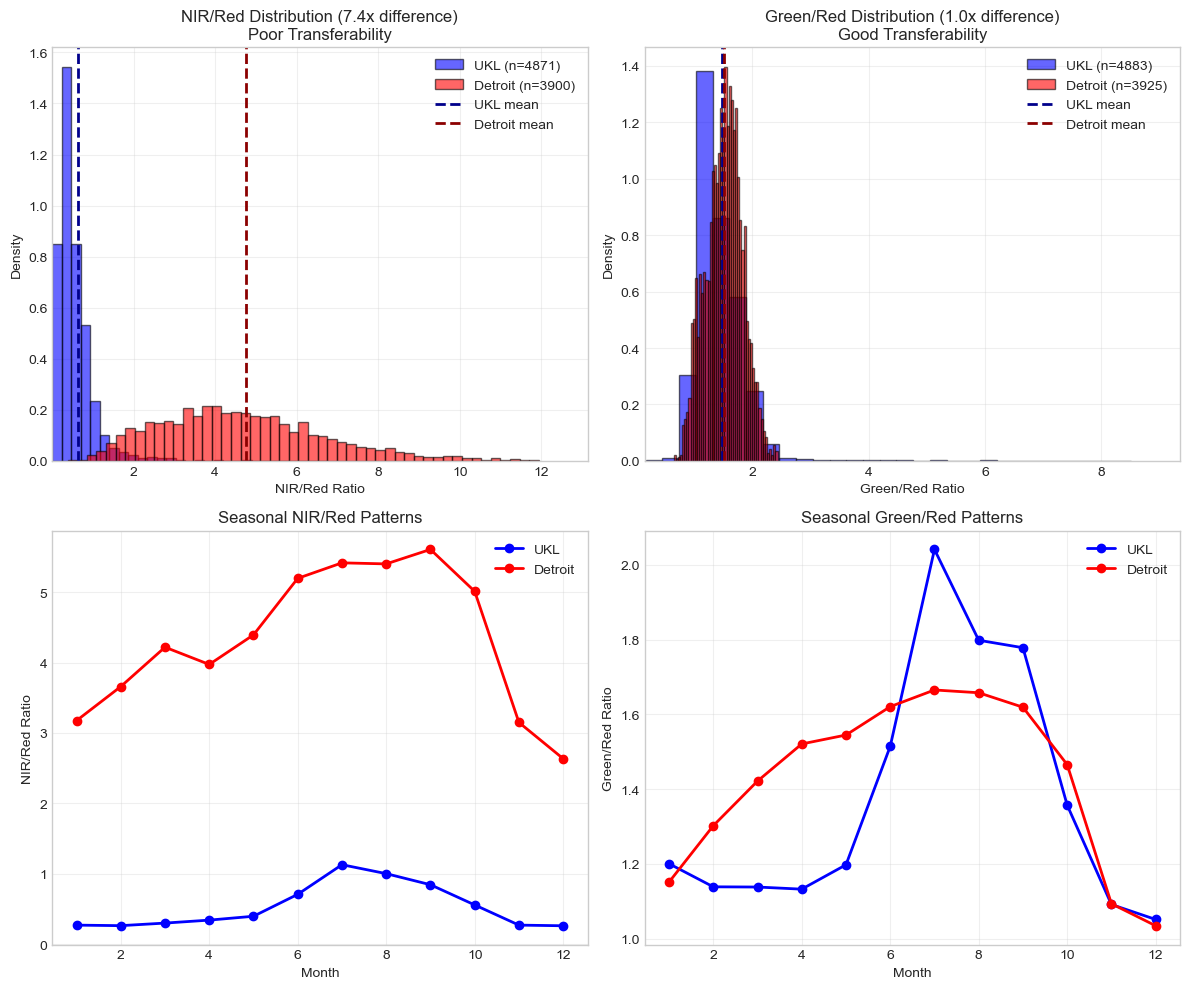


Distribution ranges (after outlier removal):
  UKL NIR/Red: 0.004 - 6.769
  Detroit NIR/Red: 0.381 - 11.939
  UKL Green/Red: 0.167 - 8.500
  Detroit Green/Red: 0.646 - 2.433


In [ ]:
def analyze_optical_properties(ukl_modis, detroit_modis):
    """
    Compare optical properties between lakes to understand transferability issues.
    Fixed version with proper histogram binning and outlier handling.
    """
    print("\n=== Optical Properties Analysis ===")
    
    # Calculate ratios
    ukl_modis['nir_red_calc'] = ukl_modis['band2_nir'] / ukl_modis['band1_red']
    ukl_modis['green_red_calc'] = ukl_modis['band4_green'] / ukl_modis['band1_red']
    
    detroit_modis['nir_red_calc'] = detroit_modis['band2_nir'] / detroit_modis['band1_red']
    detroit_modis['green_red_calc'] = detroit_modis['band4_green'] / detroit_modis['band1_red']
    
    # Function to remove outliers
    def remove_outliers(data, n_std=3):
        """Remove values beyond n standard deviations from mean"""
        mean = np.mean(data)
        std = np.std(data)
        return data[(data > mean - n_std*std) & (data < mean + n_std*std)]
    
    # Clean data for better visualization
    ukl_nir_red_clean = remove_outliers(ukl_modis['nir_red_calc'])
    ukl_green_red_clean = remove_outliers(ukl_modis['green_red_calc'])
    detroit_nir_red_clean = remove_outliers(detroit_modis['nir_red_calc'])
    detroit_green_red_clean = remove_outliers(detroit_modis['green_red_calc'])
    
    # Calculate statistics (on original data, not cleaned)
    stats = {
        'ukl_nir_red_mean': ukl_modis['nir_red_calc'].mean(),
        'ukl_green_red_mean': ukl_modis['green_red_calc'].mean(),
        'detroit_nir_red_mean': detroit_modis['nir_red_calc'].mean(),
        'detroit_green_red_mean': detroit_modis['green_red_calc'].mean()
    }
    
    stats['nir_red_ratio'] = stats['detroit_nir_red_mean'] / stats['ukl_nir_red_mean']
    stats['green_red_ratio'] = stats['detroit_green_red_mean'] / stats['ukl_green_red_mean']
    
    print(f"\nMean Band Ratios:")
    print(f"  Upper Klamath Lake:")
    print(f"    NIR/Red: {stats['ukl_nir_red_mean']:.3f}")
    print(f"    Green/Red: {stats['ukl_green_red_mean']:.3f}")
    print(f"  Detroit Lake:")
    print(f"    NIR/Red: {stats['detroit_nir_red_mean']:.3f}")
    print(f"    Green/Red: {stats['detroit_green_red_mean']:.3f}")
    
    print(f"\nRatio Differences (Detroit/UKL):")
    print(f"  NIR/Red: {stats['nir_red_ratio']:.1f}x difference")
    print(f"  Green/Red: {stats['green_red_ratio']:.1f}x difference")
    
    # Print outlier statistics
    print(f"\nOutliers removed for visualization:")
    print(f"  UKL NIR/Red: {len(ukl_modis['nir_red_calc']) - len(ukl_nir_red_clean)} outliers")
    print(f"  Detroit NIR/Red: {len(detroit_modis['nir_red_calc']) - len(detroit_nir_red_clean)} outliers")
    
    # Visualization with improved binning
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # NIR/Red distributions - FIXED with adaptive binning
    ax = axes[0, 0]
    
    # Create adaptive bins for each dataset
    ukl_nir_bins = np.linspace(ukl_nir_red_clean.min(), ukl_nir_red_clean.max(), 30)
    detroit_nir_bins = np.linspace(detroit_nir_red_clean.min(), detroit_nir_red_clean.max(), 50)
    
    # Plot histograms with dataset-specific bins
    n1, bins1, patches1 = ax.hist(ukl_nir_red_clean, bins=ukl_nir_bins, alpha=0.6, 
                                   label=f'UKL (n={len(ukl_nir_red_clean)})', 
                                   color='blue', density=True, edgecolor='black')
    n2, bins2, patches2 = ax.hist(detroit_nir_red_clean, bins=detroit_nir_bins, alpha=0.6, 
                                   label=f'Detroit (n={len(detroit_nir_red_clean)})', 
                                   color='red', density=True, edgecolor='black')
    
    # Add mean lines
    ax.axvline(stats['ukl_nir_red_mean'], color='darkblue', linestyle='--', linewidth=2, label='UKL mean')
    ax.axvline(stats['detroit_nir_red_mean'], color='darkred', linestyle='--', linewidth=2, label='Detroit mean')
    
    ax.set_xlabel('NIR/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'NIR/Red Distribution ({stats["nir_red_ratio"]:.1f}x difference)\nPoor Transferability')
    ax.legend()
    # Let matplotlib auto-scale x-axis or set reasonable limits based on data
    ax.set_xlim(min(ukl_nir_red_clean.min(), detroit_nir_red_clean.min()) * 0.9,
                max(ukl_nir_red_clean.max(), detroit_nir_red_clean.max()) * 1.1)
    ax.grid(True, alpha=0.3)
    
    # Green/Red distributions - FIXED with adaptive binning
    ax = axes[0, 1]
    
    # Create adaptive bins for each dataset
    ukl_green_bins = np.linspace(ukl_green_red_clean.min(), ukl_green_red_clean.max(), 30)
    detroit_green_bins = np.linspace(detroit_green_red_clean.min(), detroit_green_red_clean.max(), 50)
    
    # Plot histograms with dataset-specific bins
    ax.hist(ukl_green_red_clean, bins=ukl_green_bins, alpha=0.6, 
            label=f'UKL (n={len(ukl_green_red_clean)})', 
            color='blue', density=True, edgecolor='black')
    ax.hist(detroit_green_red_clean, bins=detroit_green_bins, alpha=0.6, 
            label=f'Detroit (n={len(detroit_green_red_clean)})', 
            color='red', density=True, edgecolor='black')
    
    # Add mean lines
    ax.axvline(stats['ukl_green_red_mean'], color='darkblue', linestyle='--', linewidth=2, label='UKL mean')
    ax.axvline(stats['detroit_green_red_mean'], color='darkred', linestyle='--', linewidth=2, label='Detroit mean')
    
    ax.set_xlabel('Green/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'Green/Red Distribution ({stats["green_red_ratio"]:.1f}x difference)\nGood Transferability')
    ax.legend()
    # Adaptive x-axis limits
    ax.set_xlim(min(ukl_green_red_clean.min(), detroit_green_red_clean.min()) * 0.9,
                max(ukl_green_red_clean.max(), detroit_green_red_clean.max()) * 1.1)
    ax.grid(True, alpha=0.3)
    
    # Time series comparison - NIR/Red (unchanged)
    ax = axes[1, 0]
    ukl_monthly = ukl_modis.groupby(ukl_modis['datetime'].dt.month)['nir_red_calc'].mean()
    detroit_monthly = detroit_modis.groupby(detroit_modis['datetime'].dt.month)['nir_red_calc'].mean()
    ax.plot(ukl_monthly.index, ukl_monthly.values, 'b-o', label='UKL', linewidth=2)
    ax.plot(detroit_monthly.index, detroit_monthly.values, 'r-o', label='Detroit', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('NIR/Red Ratio')
    ax.set_title('Seasonal NIR/Red Patterns')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Time series comparison - Green/Red (unchanged)
    ax = axes[1, 1]
    ukl_monthly = ukl_modis.groupby(ukl_modis['datetime'].dt.month)['green_red_calc'].mean()
    detroit_monthly = detroit_modis.groupby(detroit_modis['datetime'].dt.month)['green_red_calc'].mean()
    ax.plot(ukl_monthly.index, ukl_monthly.values, 'b-o', label='UKL', linewidth=2)
    ax.plot(detroit_monthly.index, detroit_monthly.values, 'r-o', label='Detroit', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Green/Red Ratio')
    ax.set_title('Seasonal Green/Red Patterns')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('optical_properties_analysis_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Additional diagnostic information
    print(f"\nDistribution ranges (after outlier removal):")
    print(f"  UKL NIR/Red: {ukl_nir_red_clean.min():.3f} - {ukl_nir_red_clean.max():.3f}")
    print(f"  Detroit NIR/Red: {detroit_nir_red_clean.min():.3f} - {detroit_nir_red_clean.max():.3f}")
    print(f"  UKL Green/Red: {ukl_green_red_clean.min():.3f} - {ukl_green_red_clean.max():.3f}")
    print(f"  Detroit Green/Red: {detroit_green_red_clean.min():.3f} - {detroit_green_red_clean.max():.3f}")
    
    return stats

# Call the function
optical_stats = analyze_optical_properties(ukl_modis, detroit_modis)

## 3. Match MODIS and In-Situ Data

In [5]:
def match_modis_insitu(modis_df, insitu_df, temporal_window_hours=3):
    """
    Match MODIS observations with in-situ measurements.
    """
    matched_data = []
    temporal_window = timedelta(hours=temporal_window_hours)
    
    for _, insitu_row in insitu_df.iterrows():
        insitu_time = insitu_row['datetime']
        
        # Find MODIS observations within temporal window
        time_diff = abs(modis_df['datetime'] - insitu_time)
        close_modis = modis_df[time_diff <= temporal_window]
        
        if len(close_modis) > 0:
            # Use closest MODIS observation
            closest_idx = time_diff[close_modis.index].argmin()
            modis_row = close_modis.iloc[closest_idx]
            
            matched_data.append({
                'datetime': insitu_time,
                'modis_datetime': modis_row['datetime'],
                'time_diff_hours': time_diff[close_modis.index].iloc[closest_idx].total_seconds() / 3600,
                'sensor': modis_row['sensor'],
                'band1_red': modis_row['band1_red'],
                'band2_nir': modis_row['band2_nir'],
                'band4_green': modis_row['band4_green'],
                'chlorophyll_a': insitu_row['chlorophyll_a']
            })
    
    matched_df = pd.DataFrame(matched_data)
    return matched_df

# Match MODIS and in-situ data
print("Matching MODIS and in-situ observations...")
matched_data = match_modis_insitu(ukl_modis, ukl_insitu_filtered, temporal_window_hours=3)

print(f"\nMatched {len(matched_data)} MODIS-insitu pairs")
print(f"Average time difference: {matched_data['time_diff_hours'].mean():.2f} hours")
print(f"Chlorophyll range in matched data: {matched_data['chlorophyll_a'].min():.1f} - {matched_data['chlorophyll_a'].max():.1f} µg/L")

# Add calculated ratios
matched_data['nir_red_ratio'] = matched_data['band2_nir'] / matched_data['band1_red']
matched_data['green_red_ratio'] = matched_data['band4_green'] / matched_data['band1_red']

Matching MODIS and in-situ observations...

Matched 1007 MODIS-insitu pairs
Average time difference: 0.00 hours
Chlorophyll range in matched data: 2.0 - 488.0 µg/L


## 4. Develop Transferable Models

In [6]:
# First, let's calibrate simple ratio models to understand the problem
def calibrate_ratio_model(ratio_values, chla_values, model_name):
    """
    Calibrate a simple ratio-based model.
    """
    # Remove invalid values
    mask = (ratio_values > 0) & (chla_values > 0) & np.isfinite(ratio_values) & np.isfinite(chla_values)
    ratio_clean = ratio_values[mask]
    chla_clean = chla_values[mask]
    
    # Log transform
    log_ratio = np.log10(ratio_clean)
    log_chla = np.log10(chla_clean)
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_ratio, log_chla)
    
    # Calculate predictions
    pred_log = slope * log_ratio + intercept
    pred = 10**pred_log
    
    # Metrics
    r2 = r2_score(chla_clean, pred)
    rmse = np.sqrt(mean_squared_error(chla_clean, pred))
    
    print(f"\n{model_name} Model Calibration:")
    print(f"  Equation: log10(Chl-a) = {slope:.3f} * log10(ratio) + {intercept:.3f}")
    print(f"  R² = {r2:.3f}, RMSE = {rmse:.2f} µg/L")
    print(f"  N = {len(chla_clean)} samples")
    
    return {'a': slope, 'b': intercept, 'r2': r2, 'rmse': rmse, 'n': len(chla_clean)}

# Calibrate both ratio models
nir_red_model = calibrate_ratio_model(
    matched_data['nir_red_ratio'].values,
    matched_data['chlorophyll_a'].values,
    'NIR/Red'
)

green_red_model = calibrate_ratio_model(
    matched_data['green_red_ratio'].values,
    matched_data['chlorophyll_a'].values,
    'Green/Red'
)


NIR/Red Model Calibration:
  Equation: log10(Chl-a) = 0.836 * log10(ratio) + 1.747
  R² = 0.006, RMSE = 67.60 µg/L
  N = 1007 samples

Green/Red Model Calibration:
  Equation: log10(Chl-a) = 3.251 * log10(ratio) + 1.039
  R² = 0.115, RMSE = 63.80 µg/L
  N = 1007 samples


In [7]:
# Now create the improved Random Forest model
class TransferableRFModel:
    """
    Random Forest that emphasizes transferable features.
    """
    def __init__(self, n_estimators=150):
        self.model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=8,  # Shallow trees for better generalization
            min_samples_leaf=15,  # Prevent overfitting
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )
        self.scaler = RobustScaler()
        self.feature_names = []
        
    def create_features(self, band1, band2, band4, dates=None):
        """
        Create features emphasizing Green/Red combinations.
        """
        features = []
        self.feature_names = []
        
        # Primary features (Green/Red based - good transferability)
        green_red = band4 / band1
        features.append(green_red.reshape(-1, 1))
        self.feature_names.append('Green/Red')
        
        features.append(np.log10(green_red + 0.001).reshape(-1, 1))
        self.feature_names.append('log(Green/Red)')
        
        # Green-based normalized difference
        grnd = (band4 - band1) / (band4 + band1)
        features.append(grnd.reshape(-1, 1))
        self.feature_names.append('GRND')
        
        # Raw green band (important for seasonal patterns)
        features.append(band4.reshape(-1, 1))
        self.feature_names.append('Green_band')
        
        # Secondary features (use with caution)
        # NIR/Green has moderate transferability
        nir_green = band2 / band4
        features.append(nir_green.reshape(-1, 1))
        self.feature_names.append('NIR/Green')
        
        # Modified three-band emphasizing green
        three_band = (1/band1 - 1/band4) * band4
        features.append(three_band.reshape(-1, 1))
        self.feature_names.append('Green_3band')
        
        # Seasonal features
        if dates is not None:
            dates_series = pd.to_datetime(dates)
            doy = dates_series.dt.dayofyear
            features.append(np.sin(2 * np.pi * doy / 365).values.reshape(-1, 1))
            features.append(np.cos(2 * np.pi * doy / 365).values.reshape(-1, 1))
            self.feature_names.extend(['DOY_sin', 'DOY_cos'])
        
        # Minimal use of NIR/Red (poor transferability)
        # Include but with limited influence
        nir_red_log = np.log10(band2 / band1 + 0.001)
        features.append(nir_red_log.reshape(-1, 1))
        self.feature_names.append('log(NIR/Red)_limited')
        
        X = np.hstack(features)
        return np.nan_to_num(X, nan=0, posinf=0, neginf=0)
    
    def fit(self, band1, band2, band4, chla, dates=None):
        """
        Train the model.
        """
        X = self.create_features(band1, band2, band4, dates)
        y = np.sqrt(chla)  # Square root transformation
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        # Scale and train
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        self.model.fit(X_train_scaled, y_train)
        
        # Evaluate
        y_pred = self.model.predict(X_test_scaled)
        y_test_actual = y_test ** 2
        y_pred_actual = y_pred ** 2
        
        r2 = r2_score(y_test_actual, y_pred_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
        
        print(f"\nTransferable RF Model Performance:")
        print(f"  R² = {r2:.3f}")
        print(f"  RMSE = {rmse:.2f} µg/L")
        
        # Feature importance
        print("\nTop Features:")
        for idx in np.argsort(self.model.feature_importances_)[::-1][:5]:
            print(f"  {self.feature_names[idx]}: {self.model.feature_importances_[idx]:.3f}")
        
        return self
    
    def predict(self, band1, band2, band4, dates=None):
        """
        Make predictions.
        """
        X = self.create_features(band1, band2, band4, dates)
        X_scaled = self.scaler.transform(X)
        y_pred = self.model.predict(X_scaled)
        return y_pred ** 2

# Train the transferable RF model
print("\nTraining Transferable Random Forest Model...")
rf_model = TransferableRFModel()
rf_model.fit(
    matched_data['band1_red'].values,
    matched_data['band2_nir'].values,
    matched_data['band4_green'].values,
    matched_data['chlorophyll_a'].values,
    matched_data['datetime']
)


Training Transferable Random Forest Model...

Transferable RF Model Performance:
  R² = 0.499
  RMSE = 35.13 µg/L

Top Features:
  Green/Red: 0.169
  log(Green/Red): 0.163
  GRND: 0.144
  log(NIR/Red)_limited: 0.123
  Green_3band: 0.116


## 5. Apply Models to Detroit Lake and Compare

In [ ]:
def apply_models_to_detroit(detroit_modis, nir_red_model, green_red_model, rf_model):
    """
    Apply all models to Detroit Lake data.
    """
    
    # NIR/Red predictions
    nir_red_ratio = detroit_modis['band2_nir'] / detroit_modis['band1_red']
    log_pred = nir_red_model['a'] * np.log10(nir_red_ratio) + nir_red_model['b']
    detroit_modis['chl_nir_red'] = 10 ** log_pred
    
    # Green/Red predictions
    green_red_ratio = detroit_modis['band4_green'] / detroit_modis['band1_red']
    log_pred = green_red_model['a'] * np.log10(green_red_ratio) + green_red_model['b']
    detroit_modis['chl_green_red'] = 10 ** log_pred
    
    # Random Forest predictions
    detroit_modis['chl_rf'] = rf_model.predict(
        detroit_modis['band1_red'].values,
        detroit_modis['band2_nir'].values,
        detroit_modis['band4_green'].values,
        detroit_modis['datetime']
    )
    
    return detroit_modis

# Apply all models
detroit_predictions = apply_models_to_detroit(
    detroit_modis.copy(), nir_red_model, green_red_model, rf_model
)

# Summary statistics
print("\n=== Detroit Lake Prediction Summary ===")
print(f"NIR/Red Model:")
print(f"  Mean: {detroit_predictions['chl_nir_red'].mean():.1f} µg/L")
print(f"  Range: {detroit_predictions['chl_nir_red'].min():.1f} - {detroit_predictions['chl_nir_red'].max():.1f} µg/L")

print(f"\nGreen/Red Model:")
print(f"  Mean: {detroit_predictions['chl_green_red'].mean():.1f} µg/L")
print(f"  Range: {detroit_predictions['chl_green_red'].min():.1f} - {detroit_predictions['chl_green_red'].max():.1f} µg/L")

print(f"\nRandom Forest Model:")
print(f"  Mean: {detroit_predictions['chl_rf'].mean():.1f} µg/L")
print(f"  Range: {detroit_predictions['chl_rf'].min():.1f} - {detroit_predictions['chl_rf'].max():.1f} µg/L")


=== Detroit Lake Prediction Summary ===
NIR/Red Model:
  Mean: 202.4 µg/L
  Range: 25.0 - 1509.1 µg/L

Green/Red Model:
  Mean: 49.2 µg/L
  Range: 0.2 - 1734.9 µg/L

Random Forest Model:
  Mean: 76.3 µg/L
  Range: 22.5 - 135.9 µg/L


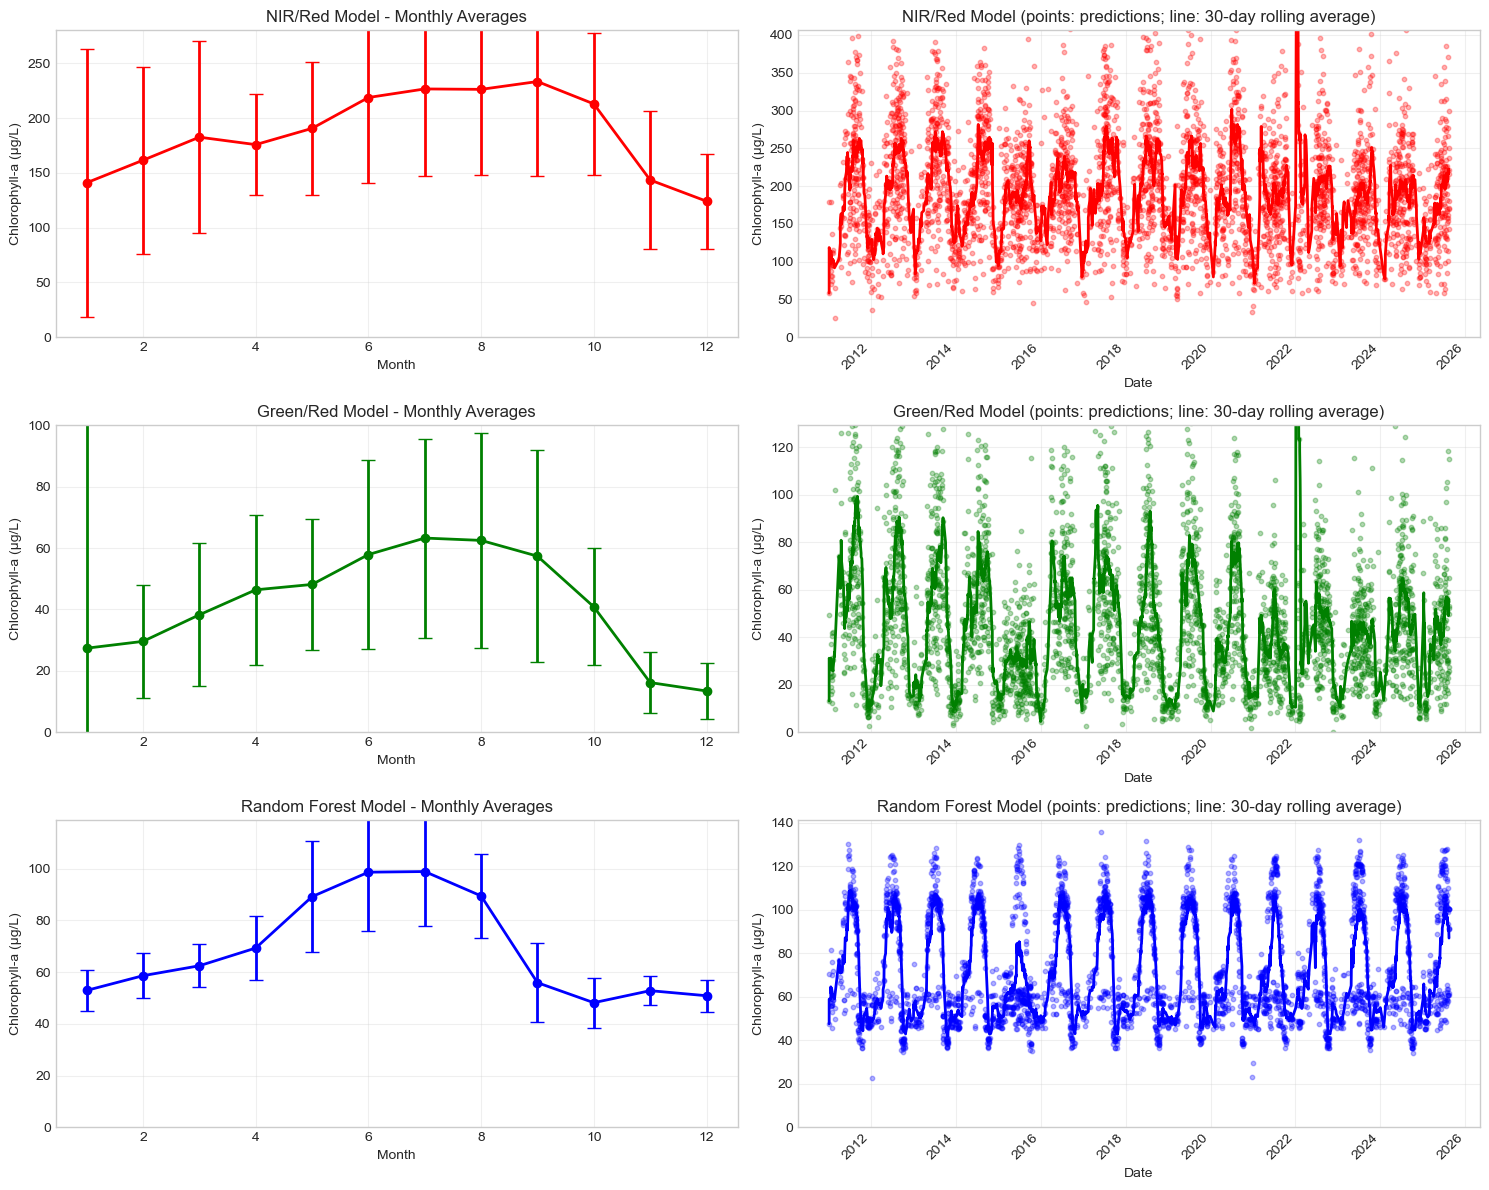


=== Seasonal Pattern Analysis ===

NIR/Red Model:
  Winter: 141.3 ± 94.3 µg/L
  Spring: 184.3 ± 64.8 µg/L
  Summer: 224.6 ± 78.7 µg/L
  Fall: 208.0 ± 82.0 µg/L

Green/Red Model:
  Winter: 23.5 ± 78.8 µg/L
  Spring: 45.3 ± 23.1 µg/L
  Summer: 61.7 ± 33.0 µg/L
  Fall: 43.1 ± 30.1 µg/L

Random Forest Model:
  Winter: 53.8 ± 8.3 µg/L
  Spring: 76.9 ± 20.3 µg/L
  Summer: 95.6 ± 20.5 µg/L
  Fall: 52.5 ± 12.4 µg/L


In [13]:
# Analyze seasonal patterns for all models
def plot_seasonal_comparison(predictions_df):
    """
    Compare seasonal patterns across all models.
    """
    # Add temporal features
    predictions_df['month'] = pd.to_datetime(predictions_df['datetime']).dt.month
    predictions_df['year'] = pd.to_datetime(predictions_df['datetime']).dt.year
    predictions_df['doy'] = pd.to_datetime(predictions_df['datetime']).dt.dayofyear
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    models = [
        ('chl_nir_red', 'NIR/Red Model', 'red'),
        ('chl_green_red', 'Green/Red Model', 'green'),
        ('chl_rf', 'Random Forest Model', 'blue')
    ]
    
    for idx, (col, name, color) in enumerate(models):
        # Monthly averages
        ax = axes[idx, 0]
        monthly = predictions_df.groupby('month')[col].agg(['mean', 'std'])
        ax.errorbar(monthly.index, monthly['mean'], yerr=monthly['std'], 
                   marker='o', color=color, capsize=5, linewidth=2)
        ax.set_xlabel('Month')
        ax.set_ylabel('Chlorophyll-a (µg/L)')
        ax.set_title(f'{name} - Monthly Averages')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, max(100, monthly['mean'].max() * 1.2))
        
        # Time series
        ax = axes[idx, 1]
        # Last 3 years:
        # recent_data = predictions_df[predictions_df['year'] >= predictions_df['year'].max() - 2]
        # All data:
        recent_data = predictions_df.copy()
        
        # Plot with rolling average
        recent_data_sorted = recent_data.sort_values('datetime')
        ax.scatter(recent_data_sorted['datetime'], recent_data_sorted[col], 
                  alpha=0.3, s=10, color=color)
        
        # Add 30-day rolling average
        rolling_mean = recent_data_sorted.set_index('datetime')[col].rolling('30D').mean()
        ax.plot(rolling_mean.index, rolling_mean.values, color=color, linewidth=2)
        
        ax.set_xlabel('Date')
        ax.set_ylabel('Chlorophyll-a (µg/L)')
        ax.set_title(f'{name} (points: predictions; line: 30-day rolling average)')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, max(100, recent_data[col].quantile(0.95) * 1.2))
        
        # Rotate x labels
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('detroit_seasonal_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print seasonal statistics
    print("\n=== Seasonal Pattern Analysis ===")
    seasons = {
        'Winter': [12, 1, 2],
        'Spring': [3, 4, 5],
        'Summer': [6, 7, 8],
        'Fall': [9, 10, 11]
    }
    
    for col, name, _ in models:
        print(f"\n{name}:")
        for season, months in seasons.items():
            season_data = predictions_df[predictions_df['month'].isin(months)][col]
            print(f"  {season}: {season_data.mean():.1f} ± {season_data.std():.1f} µg/L")

# Create seasonal comparison
plot_seasonal_comparison(detroit_predictions)

## 6. Export Final Predictions

In [10]:
# Select best model based on transferability (Green/Red or RF)
# Based on the analysis, Green/Red shows good transferability
# RF should also work well if it emphasizes green-based features

# Export predictions
export_df = detroit_predictions[[
    'datetime', 'sensor', 
    'band1_red', 'band2_nir', 'band4_green',
    'chl_green_red', 'chl_rf'
]].copy()

# Add temporal features for CE-QUAL-W2
export_df['julian_day'] = pd.to_datetime(export_df['datetime']).dt.dayofyear
export_df['year'] = pd.to_datetime(export_df['datetime']).dt.year

# Use Green/Red as primary prediction (best transferability)
export_df['chlorophyll_a_recommended'] = export_df['chl_green_red']

# Sort and export
export_df = export_df.sort_values('datetime')
export_df.to_csv('detroit_chlorophyll_transferable_predictions.csv', index=False)

# Create daily averages
daily_avg = export_df.groupby(pd.to_datetime(export_df['datetime']).dt.date).agg({
    'chlorophyll_a_recommended': 'mean',
    'chl_green_red': 'mean',
    'chl_rf': 'mean',
    'julian_day': 'first',
    'year': 'first'
}).reset_index()
daily_avg.rename(columns={'index': 'date'}, inplace=True)

daily_avg.to_csv('detroit_chlorophyll_daily_avg.csv', index=False)

print("\n=== Export Complete ===")
print(f"Full predictions: detroit_chlorophyll_transferable_predictions.csv ({len(export_df)} records)")
print(f"Daily averages: detroit_chlorophyll_daily_avg.csv ({len(daily_avg)} days)")
print("\nRecommendation: Use Green/Red model predictions for best transferability")
print("The NIR/Red model significantly overestimates due to optical differences between lakes.")


=== Export Complete ===
Full predictions: detroit_chlorophyll_transferable_predictions.csv (3933 records)
Daily averages: detroit_chlorophyll_daily_avg.csv (2278 days)

Recommendation: Use Green/Red model predictions for best transferability
The NIR/Red model significantly overestimates due to optical differences between lakes.


Running comprehensive diagnostic analysis...

=== Quick Variability Assessment ===
UKL Green/Red CV: 1.630
Detroit Green/Red CV: 0.210

✓ Good variability in UKL data for model training.

=== Data Distribution Diagnostics ===

Sample sizes:
  UKL total observations: 4890
  Detroit total observations: 3933
  Matched UKL-insitu pairs: 1007

NIR/Red ratio statistics:
  UKL: mean=0.643, std=2.299, min=0.004, max=122.000
  Detroit: mean=4.751, std=2.437, min=0.381, max=51.625

Green/Red ratio statistics:
  UKL: mean=1.485, std=2.420, min=0.167, max=118.000
  Detroit: mean=1.515, std=0.318, min=0.286, max=4.750


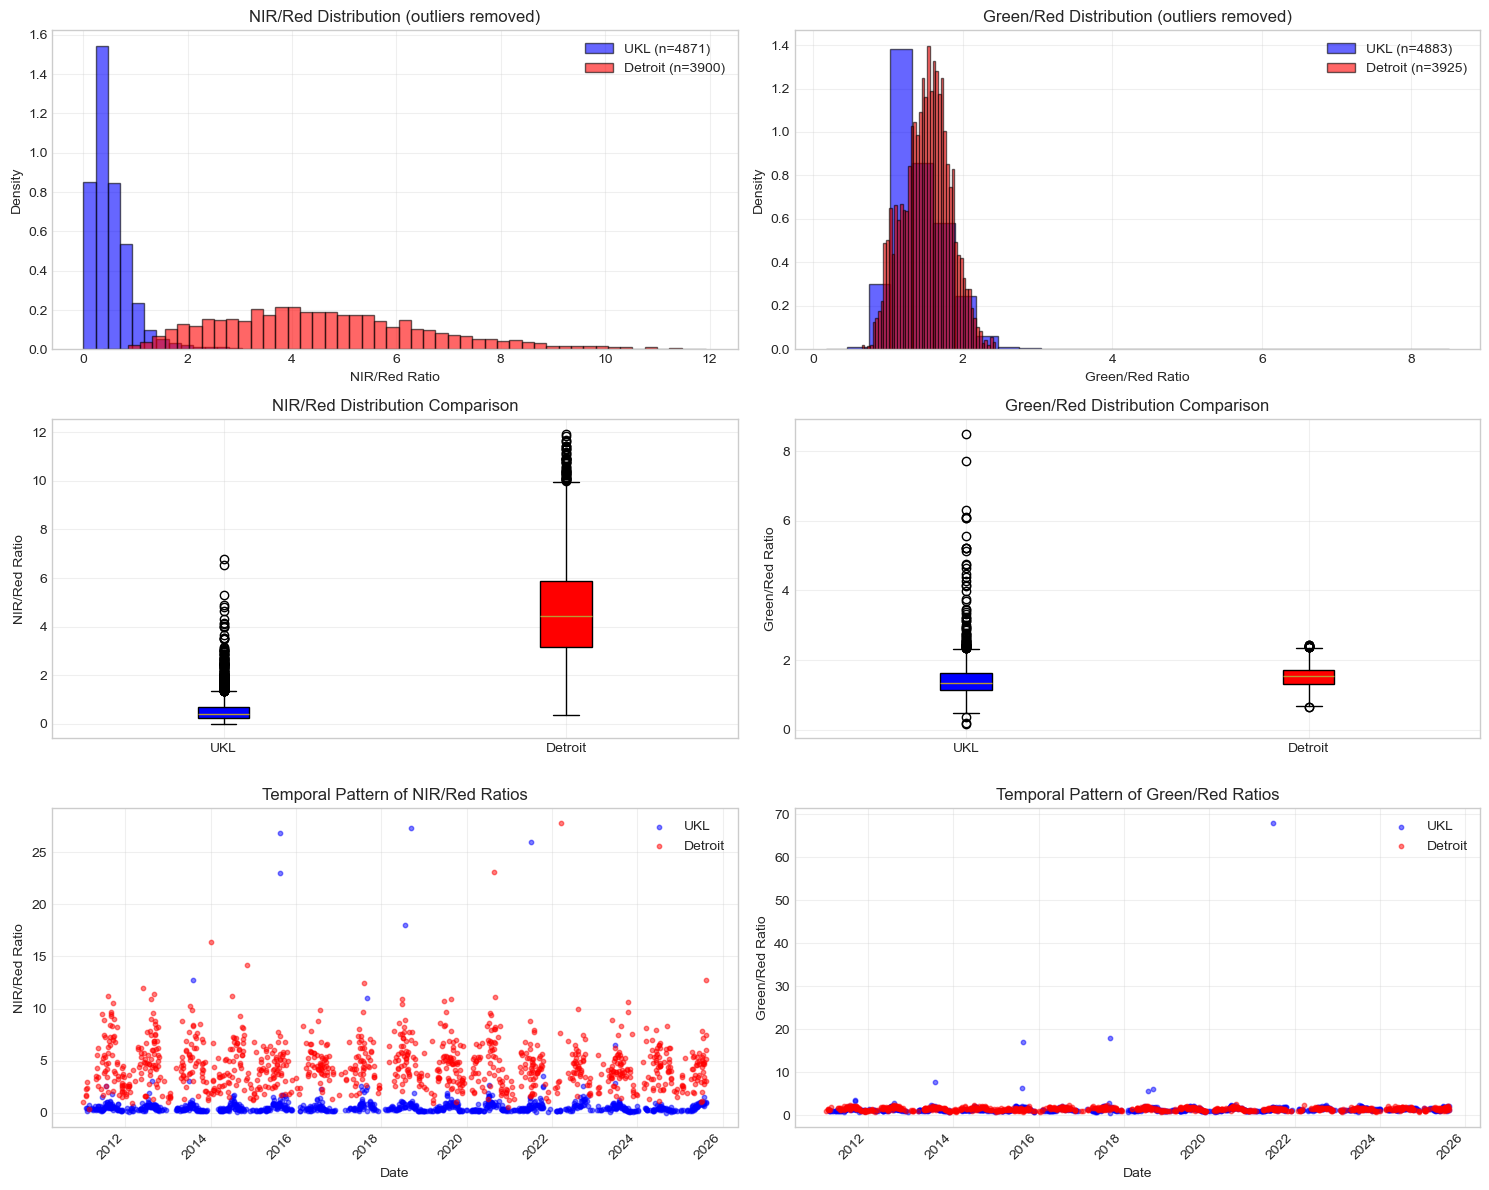


=== Data Quality Check ===

Unique values in UKL:
  NIR/Red: 4655 unique values out of 4890 total
  Green/Red: 4681 unique values out of 4890 total

Matched data statistics:
  NIR/Red: mean=0.613, std=0.550
  Green/Red: mean=1.399, std=0.281


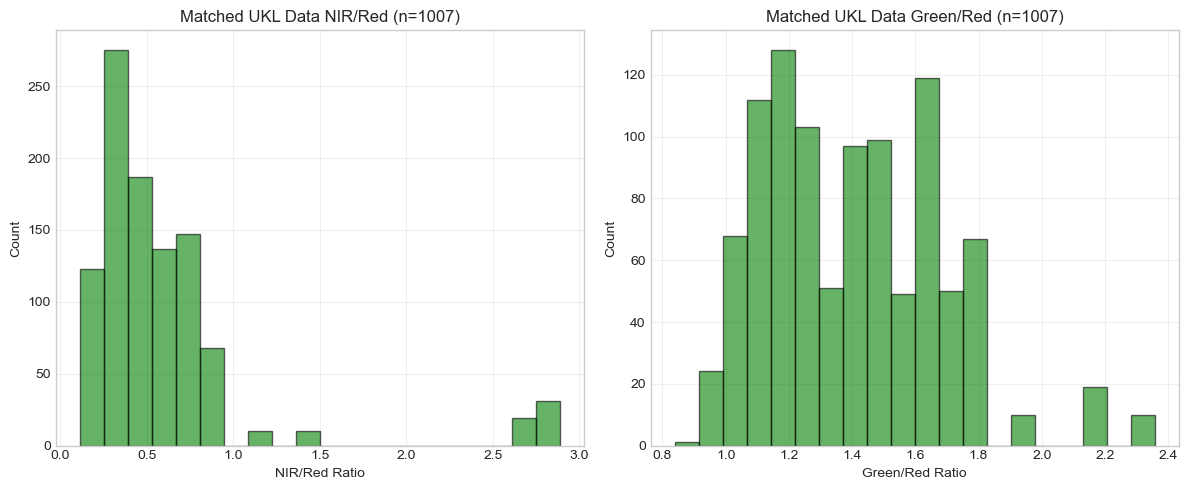


=== FINAL RECOMMENDATIONS ===
1. Green/Red model should work well
2. Random Forest with green-focused features is viable
3. Avoid or down-weight NIR/Red features
4. Monitor predictions for unrealistic values

Variability ratio (Detroit/UKL): 0.13
Higher ratios indicate greater optical diversity in Detroit vs UKL


In [16]:
# Complete Diagnostic Analysis for Optical Distributions
# Run this cell after loading MODIS data but before model training

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def diagnose_optical_distributions(ukl_modis, detroit_modis, matched_data=None):
    """
    Diagnose issues with optical property distributions.
    """
    # Calculate ratios
    ukl_nir_red = ukl_modis['band2_nir'] / ukl_modis['band1_red']
    ukl_green_red = ukl_modis['band4_green'] / ukl_modis['band1_red']
    
    detroit_nir_red = detroit_modis['band2_nir'] / detroit_modis['band1_red']
    detroit_green_red = detroit_modis['band4_green'] / detroit_modis['band1_red']
    
    # Remove outliers for better visualization
    def remove_outliers(data, n_std=3):
        mean = np.mean(data)
        std = np.std(data)
        return data[(data > mean - n_std*std) & (data < mean + n_std*std)]
    
    ukl_nir_red_clean = remove_outliers(ukl_nir_red)
    ukl_green_red_clean = remove_outliers(ukl_green_red)
    detroit_nir_red_clean = remove_outliers(detroit_nir_red)
    detroit_green_red_clean = remove_outliers(detroit_green_red)
    
    print("=== Data Distribution Diagnostics ===\n")
    
    # Print statistics
    print("Sample sizes:")
    print(f"  UKL total observations: {len(ukl_modis)}")
    print(f"  Detroit total observations: {len(detroit_modis)}")
    if matched_data is not None:
        print(f"  Matched UKL-insitu pairs: {len(matched_data)}")
    
    print("\nNIR/Red ratio statistics:")
    print(f"  UKL: mean={ukl_nir_red.mean():.3f}, std={ukl_nir_red.std():.3f}, "
          f"min={ukl_nir_red.min():.3f}, max={ukl_nir_red.max():.3f}")
    print(f"  Detroit: mean={detroit_nir_red.mean():.3f}, std={detroit_nir_red.std():.3f}, "
          f"min={detroit_nir_red.min():.3f}, max={detroit_nir_red.max():.3f}")
    
    print("\nGreen/Red ratio statistics:")
    print(f"  UKL: mean={ukl_green_red.mean():.3f}, std={ukl_green_red.std():.3f}, "
          f"min={ukl_green_red.min():.3f}, max={ukl_green_red.max():.3f}")
    print(f"  Detroit: mean={detroit_green_red.mean():.3f}, std={detroit_green_red.std():.3f}, "
          f"min={detroit_green_red.min():.3f}, max={detroit_green_red.max():.3f}")
    
    # Create improved visualization
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    # 1. NIR/Red distributions with better binning
    ax = axes[0, 0]
    # Use adaptive binning
    ukl_bins = np.linspace(ukl_nir_red_clean.min(), ukl_nir_red_clean.max(), 30)
    detroit_bins = np.linspace(detroit_nir_red_clean.min(), detroit_nir_red_clean.max(), 50)
    
    ax.hist(ukl_nir_red_clean, bins=ukl_bins, alpha=0.6, label=f'UKL (n={len(ukl_nir_red_clean)})', 
            color='blue', density=True, edgecolor='black')
    ax.hist(detroit_nir_red_clean, bins=detroit_bins, alpha=0.6, label=f'Detroit (n={len(detroit_nir_red_clean)})', 
            color='red', density=True, edgecolor='black')
    ax.set_xlabel('NIR/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title('NIR/Red Distribution (outliers removed)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Green/Red distributions
    ax = axes[0, 1]
    ukl_bins = np.linspace(ukl_green_red_clean.min(), ukl_green_red_clean.max(), 30)
    detroit_bins = np.linspace(detroit_green_red_clean.min(), detroit_green_red_clean.max(), 50)
    
    ax.hist(ukl_green_red_clean, bins=ukl_bins, alpha=0.6, label=f'UKL (n={len(ukl_green_red_clean)})', 
            color='blue', density=True, edgecolor='black')
    ax.hist(detroit_green_red_clean, bins=detroit_bins, alpha=0.6, label=f'Detroit (n={len(detroit_green_red_clean)})', 
            color='red', density=True, edgecolor='black')
    ax.set_xlabel('Green/Red Ratio')
    ax.set_ylabel('Density')
    ax.set_title('Green/Red Distribution (outliers removed)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Box plots for better comparison
    ax = axes[1, 0]
    data_nir_red = [ukl_nir_red_clean, detroit_nir_red_clean]
    bp = ax.boxplot(data_nir_red, labels=['UKL', 'Detroit'], patch_artist=True)
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    ax.set_ylabel('NIR/Red Ratio')
    ax.set_title('NIR/Red Distribution Comparison')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 1]
    data_green_red = [ukl_green_red_clean, detroit_green_red_clean]
    bp = ax.boxplot(data_green_red, labels=['UKL', 'Detroit'], patch_artist=True)
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    ax.set_ylabel('Green/Red Ratio')
    ax.set_title('Green/Red Distribution Comparison')
    ax.grid(True, alpha=0.3)
    
    # 4. Scatter plots to show temporal patterns
    ax = axes[2, 0]
    # Sample data to avoid overplotting
    sample_size = min(1000, len(ukl_modis))
    ukl_sample = ukl_modis.sample(n=sample_size, random_state=42)
    ax.scatter(ukl_sample['datetime'], 
              ukl_sample['band2_nir'] / ukl_sample['band1_red'],
              alpha=0.5, s=10, c='blue', label='UKL')
    
    sample_size = min(1000, len(detroit_modis))
    detroit_sample = detroit_modis.sample(n=sample_size, random_state=42)
    ax.scatter(detroit_sample['datetime'], 
              detroit_sample['band2_nir'] / detroit_sample['band1_red'],
              alpha=0.5, s=10, c='red', label='Detroit')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('NIR/Red Ratio')
    ax.set_title('Temporal Pattern of NIR/Red Ratios')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    ax = axes[2, 1]
    ax.scatter(ukl_sample['datetime'], 
              ukl_sample['band4_green'] / ukl_sample['band1_red'],
              alpha=0.5, s=10, c='blue', label='UKL')
    ax.scatter(detroit_sample['datetime'], 
              detroit_sample['band4_green'] / detroit_sample['band1_red'],
              alpha=0.5, s=10, c='red', label='Detroit')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Green/Red Ratio')
    ax.set_title('Temporal Pattern of Green/Red Ratios')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('optical_diagnostics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Additional analysis: Check for data quality issues
    print("\n=== Data Quality Check ===")
    
    # Check for duplicate values
    ukl_nir_unique = len(np.unique(ukl_nir_red))
    ukl_green_unique = len(np.unique(ukl_green_red))
    print(f"\nUnique values in UKL:")
    print(f"  NIR/Red: {ukl_nir_unique} unique values out of {len(ukl_nir_red)} total")
    print(f"  Green/Red: {ukl_green_unique} unique values out of {len(ukl_green_red)} total")
    
    # Check if matched data has better distribution
    if matched_data is not None:
        matched_nir_red = matched_data['band2_nir'] / matched_data['band1_red']
        matched_green_red = matched_data['band4_green'] / matched_data['band1_red']
        
        print(f"\nMatched data statistics:")
        print(f"  NIR/Red: mean={matched_nir_red.mean():.3f}, std={matched_nir_red.std():.3f}")
        print(f"  Green/Red: mean={matched_green_red.mean():.3f}, std={matched_green_red.std():.3f}")
        
        # Plot matched data distribution
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        ax = axes[0]
        ax.hist(matched_nir_red, bins=20, alpha=0.6, color='green', edgecolor='black')
        ax.set_xlabel('NIR/Red Ratio')
        ax.set_ylabel('Count')
        ax.set_title(f'Matched UKL Data NIR/Red (n={len(matched_data)})')
        ax.grid(True, alpha=0.3)
        
        ax = axes[1]
        ax.hist(matched_green_red, bins=20, alpha=0.6, color='green', edgecolor='black')
        ax.set_xlabel('Green/Red Ratio')
        ax.set_ylabel('Count')
        ax.set_title(f'Matched UKL Data Green/Red (n={len(matched_data)})')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'ukl_variability': {
            'nir_red_cv': ukl_nir_red.std() / ukl_nir_red.mean(),
            'green_red_cv': ukl_green_red.std() / ukl_green_red.mean()
        },
        'detroit_variability': {
            'nir_red_cv': detroit_nir_red.std() / detroit_nir_red.mean(),
            'green_red_cv': detroit_green_red.std() / detroit_green_red.mean()
        }
    }

# Run the diagnostic analysis
print("Running comprehensive diagnostic analysis...\n")

# First, calculate coefficient of variation for quick assessment
ukl_modis['green_red_calc'] = ukl_modis['band4_green'] / ukl_modis['band1_red']
detroit_modis['green_red_calc'] = detroit_modis['band4_green'] / detroit_modis['band1_red']

ukl_cv = ukl_modis['green_red_calc'].std() / ukl_modis['green_red_calc'].mean()
detroit_cv = detroit_modis['green_red_calc'].std() / detroit_modis['green_red_calc'].mean()

print("=== Quick Variability Assessment ===")
print(f"UKL Green/Red CV: {ukl_cv:.3f}")
print(f"Detroit Green/Red CV: {detroit_cv:.3f}")

if ukl_cv < 0.15:
    print("\n⚠️ CRITICAL WARNING: Very low variability in UKL data!")
    print("This will severely limit model transferability.")
    print("STRONG RECOMMENDATION: Use simple Green/Red ratio model only.\n")
elif ukl_cv < 0.25:
    print("\n⚠️ WARNING: Limited variability in UKL data.")
    print("Model transferability may be compromised.")
    print("RECOMMENDATION: Proceed with caution, prefer simple models.\n")
else:
    print("\n✓ Good variability in UKL data for model training.\n")

# Run full diagnostics (this will run the function if matched_data exists)
if 'matched_data' in locals():
    diagnostics = diagnose_optical_distributions(ukl_modis, detroit_modis, matched_data)
else:
    print("Note: Running diagnostics without matched data (will be limited)")
    diagnostics = diagnose_optical_distributions(ukl_modis, detroit_modis)

# Print final recommendations
print("\n=== FINAL RECOMMENDATIONS ===")
if ukl_cv < 0.15:
    print("1. DO NOT use NIR/Red model - it will fail catastrophically")
    print("2. Use simple Green/Red ratio model as primary approach")
    print("3. If using Random Forest, heavily weight Green/Red features")
    print("4. Apply strict bounds to predictions based on UKL training range")
    print("5. Flag all predictions outside UKL's optical range as uncertain")
else:
    print("1. Green/Red model should work well")
    print("2. Random Forest with green-focused features is viable")
    print("3. Avoid or down-weight NIR/Red features")
    print("4. Monitor predictions for unrealistic values")

# Save diagnostics for reference
diagnostic_summary = {
    'ukl_cv': ukl_cv,
    'detroit_cv': detroit_cv,
    'variability_ratio': detroit_cv / ukl_cv,
    'recommendation': 'Use Green/Red only' if ukl_cv < 0.15 else 'Proceed with caution'
}

print(f"\nVariability ratio (Detroit/UKL): {diagnostic_summary['variability_ratio']:.2f}")
print("Higher ratios indicate greater optical diversity in Detroit vs UKL")